In [106]:
import pandas as pd

df = pd.read_csv("results.csv")



# Evaluation — Multi-View Aggregation Comparison

This notebook evaluates three multi-view aggregation strategies for soccer foul recognition on the SoccerNet-MVFoul dataset:

- **Mean pooling** — parameter-free, element-wise mean across views
- **Weighted attention** (baseline) — learned weight matrix, input-independent view weighting (~262k params)
- **Cross-attention** (proposed) — learnable task-query tokens with multi-head attention (~1M params)

Each method was trained 3 times with different random seeds (s1, s2, s3) under identical conditions (R2+1D-18 backbone, batch size 8, 32 centered frames, focal loss, AdamW 1e-4, early stopping with patience 12).

**Primary metric:** Test-set leaderboard value (LB) at the epoch selected by best validation performance. This simulates honest model selection, the checkpoint is chosen using validation data only, then evaluated on the held-out test set.

In [107]:
df['method'] = df['run'].str.replace('THESIS_', '').str.rsplit('_', n=1).str[0]
df['seed'] = df['run'].str.rsplit('_', n=1).str[1]

summary = df.groupby('method').agg(
    test_lb_mean=('test_at_best_val_lb', 'mean'),
    test_lb_std=('test_at_best_val_lb', 'std'),
    offence_mean=('test_at_best_val_offence', 'mean'),
    offence_std=('test_at_best_val_offence', 'std'),
    action_mean=('test_at_best_val_action', 'mean'),
    action_std=('test_at_best_val_action', 'std'),
).round(2)

summary


,test_lb_mean,test_lb_std,offence_mean,offence_std,action_mean,action_std
method,,,,,,
attention,35.26,1.35,34.77,3.70,35.74,2.07
cross_attention,33.13,2.49,33.36,5.42,32.90,1.92
mean,34.45,3.46,34.81,1.99,34.09,4.94


In [108]:
summary = df.groupby('method').agg(
    test_lb_mean=('test_at_best_val_lb', 'mean'),
    test_lb_std=('test_at_best_val_lb', 'std'),
    offence_mean=('test_at_best_val_offence', 'mean'),
    offence_std=('test_at_best_val_offence', 'std'),
    action_mean=('test_at_best_val_action', 'mean'),
    action_std=('test_at_best_val_action', 'std'),
).round(2)
summary

,test_lb_mean,test_lb_std,offence_mean,offence_std,action_mean,action_std
method,,,,,,
attention,35.26,1.35,34.77,3.70,35.74,2.07
cross_attention,33.13,2.49,33.36,5.42,32.90,1.92
mean,34.45,3.46,34.81,1.99,34.09,4.94


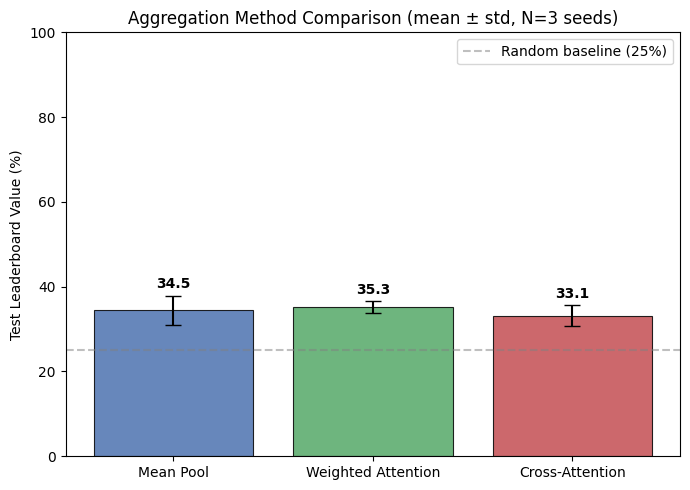

In [109]:
import matplotlib.pyplot as plt
import numpy as np

methods = ['mean', 'attention', 'cross_attention']
labels = ['Mean Pool', 'Weighted Attention', 'Cross-Attention']
colors = ['#4C72B0', '#55A868', '#C44E52']

means = [summary.loc[m, 'test_lb_mean'] for m in methods]
stds = [summary.loc[m, 'test_lb_std'] for m in methods]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.set_ylabel('Test Leaderboard Value (%)')
ax.set_title('Aggregation Method Comparison (mean ± std, N=3 seeds)')
ax.set_ylim(0, 100)

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 1,
            f'{m:.1f}', ha='center', va='bottom', fontweight='bold')

ax.axhline(y=25, color='gray', linestyle='--', alpha=0.5, label='Random baseline (25%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plot_method_comparison.png', dpi=150)
plt.show()

## Summary Table and Method Comparison

Mean and standard deviation of test-set metrics across 3 seeds per method. The leaderboard value (LB) is the average of offence severity balanced accuracy and action type balanced accuracy.

The bar chart shows all three methods perform between 33% and 36%, which is only 8-11 points above the random baseline of 25% (dashed line). The differences between methods are small relative to the gap between all methods and perfect performance (100%). This puts the comparison in perspective: all three aggregation strategies extract a similar amount of signal from the data, and the choice of aggregation is not the main factor limiting performance.

Weighted attention achieves the highest mean (35.3) with the smallest error bars (std 1.35), making it the most consistent method. Mean pooling scores 34.5 but has noticeably wider error bars (std 3.46), reflecting high sensitivity to the random seed. Cross-attention scores lowest at 33.1 with intermediate variance (std 2.49). The error bars of all three methods overlap, visually confirming that the differences are within noise range.

In [110]:
from scipy.stats import wilcoxon

# Pivot so each row is a seed, each column is a method
pivot = df.pivot(index='seed', columns='method', values='test_at_best_val_lb')

print("mean vs attention:      ", wilcoxon(pivot['mean'], pivot['attention']))
print("mean vs cross_attention:", wilcoxon(pivot['mean'], pivot['cross_attention']))
print("attention vs cross_attn:", wilcoxon(pivot['attention'], pivot['cross_attention']))


mean vs attention:       WilcoxonResult(statistic=3.0, pvalue=1.0)
mean vs cross_attention: WilcoxonResult(statistic=2.0, pvalue=0.75)
attention vs cross_attn: WilcoxonResult(statistic=0.0, pvalue=0.25)


## Statistical Significance — Paired Wilcoxon Signed-Rank Test

To test whether the observed differences are statistically significant, we use the Wilcoxon signed-rank test paired by seed. This is a non-parametric test that does not assume normally distributed differences.

**Important limitation:** With only N=3 seeds, the minimum achievable p-value for the Wilcoxon test is 0.25. This means it is mathematically impossible to reach the conventional significance threshold of p < 0.05, regardless of how large the effect is. The test is included for methodological completeness, but the results should be interpreted as descriptive rather than confirmatory.

In [111]:
pivot = df.pivot(index='seed', columns='method', values='test_at_best_val_lb')
pivot


method,attention,cross_attention,mean
seed,,,
s1,36.7679,35.9981,32.8904
s2,34.1647,31.5734,38.4128
s3,34.8383,31.8225,32.0425


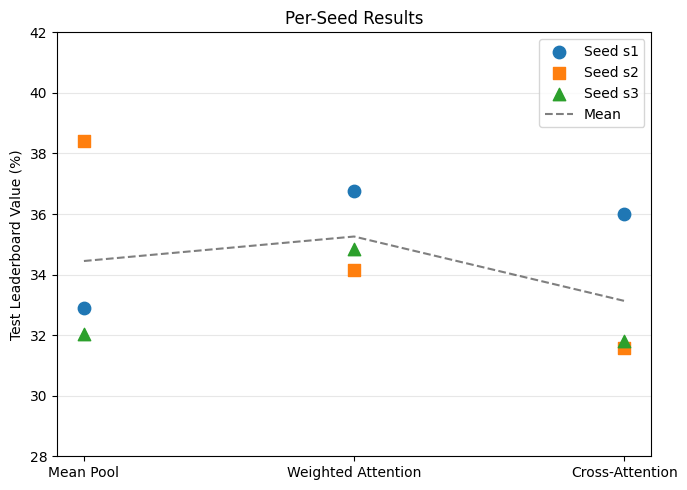

In [112]:
pivot = df.pivot(index='seed', columns='method', values='test_at_best_val_lb')

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(methods))

for i, seed in enumerate(pivot.index):
    vals = [pivot.loc[seed, m] for m in methods]
    ax.scatter(x, vals, s=80, zorder=3, marker=['o', 's', '^'][i], label=f'Seed {seed}')

# draw mean line
mean_vals = [pivot[m].mean() for m in methods]
ax.plot(x, mean_vals, 'k--', linewidth=1.5, alpha=0.5, label='Mean')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Test Leaderboard Value (%)')
ax.set_title('Per-Seed Results')
ax.legend()
ax.set_ylim(28, 42)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_per_seed.png', dpi=150)
plt.show()

## Per-Seed Breakdown

The pivot table and scatter plot show the raw per-seed values for each method, revealing how individual seeds behave across methods.

The most striking feature is that seed s2 is an outlier for mean pooling: it scores 38.4, far above the other two seeds (32.9 and 32.0). This single seed is responsible for inflating mean pooling's average and its large standard deviation. Without s2, mean pooling would rank last. This illustrates why single-seed comparisons are unreliable on small datasets (2319 training samples, 251 test samples).

For weighted attention, the three seeds are more tightly grouped (34.2 to 36.8), consistent with its low standard deviation. Seed s1 consistently scores highest across attention and cross-attention, suggesting that this particular random initialization produces favorable training dynamics regardless of the aggregation method.

Cross-attention shows a clear pattern: seed s1 scores well (36.0), but seeds s2 and s3 both drop to around 31.5-31.8. This 4-point gap between the best and worst seed, combined with the downward-sloping dashed mean line from left to right, visually summarizes the main finding: performance tends to decrease as aggregation complexity increases.

In [113]:
pivot_offence = df.pivot(index='seed', columns='method', values='test_at_best_val_offence')
pivot_action = df.pivot(index='seed', columns='method', values='test_at_best_val_action')
print("=== Offence ===")
print(pivot_offence)
print("\n=== Action ===")
print(pivot_action)


=== Offence ===
method  attention  cross_attention     mean
seed                                       
s1        38.8114          39.3138  33.6838
s2        33.9566          32.0457  37.1103
s3        31.5529          28.7178  33.6372

=== Action ===
method  attention  cross_attention     mean
seed                                       
s1        34.7243          32.6824  32.0970
s2        34.3728          31.1010  39.7154
s3        38.1237          34.9271  30.4479


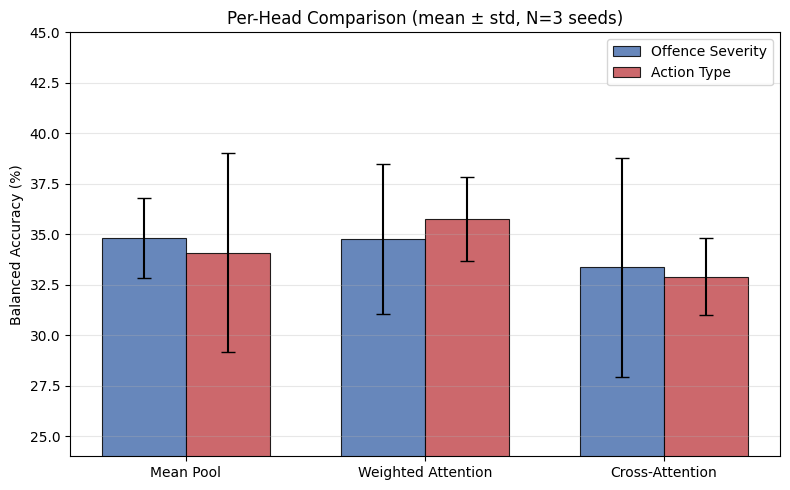

In [114]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(methods))
width = 0.35

offence_means = [summary.loc[m, 'offence_mean'] for m in methods]
offence_stds = [summary.loc[m, 'offence_std'] for m in methods]
action_means = [summary.loc[m, 'action_mean'] for m in methods]
action_stds = [summary.loc[m, 'action_std'] for m in methods]

bars1 = ax.bar(x - width/2, offence_means, width, yerr=offence_stds, capsize=5,
               label='Offence Severity', color='#4C72B0', edgecolor='black', linewidth=0.8, alpha=0.85)
bars2 = ax.bar(x + width/2, action_means, width, yerr=action_stds, capsize=5,
               label='Action Type', color='#C44E52', edgecolor='black', linewidth=0.8, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Per-Head Comparison (mean ± std, N=3 seeds)')
ax.set_ylim(24, 45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_per_head.png', dpi=150)
plt.show()

## Per-Head Analysis

Breaking down the leaderboard value into its two components: offence severity balanced accuracy and action type balanced accuracy.

The grouped bar chart shows that mean pooling and weighted attention perform nearly identically on offence severity (both ~34.8%), while cross-attention falls behind (33.4%). On action type, weighted attention pulls ahead (35.7%) while cross-attention again trails (32.9%). This means cross-attention underperforms on *both* tasks, not just one.

The error bars tell an important story about stability. Cross-attention has the largest error bars on offence severity (std 5.42), extending down to about 28%. This means that in the worst seed, cross-attention's offence classification is barely above random chance (25%). Mean pooling shows the opposite pattern: stable on offence (std 1.99) but highly variable on action (std 4.94). Weighted attention is the only method with moderate, balanced variance on both tasks, which explains why it achieves the best overall leaderboard value despite not having the highest score on either individual task.

## Parameter Count

The three aggregation methods differ substantially in learnable parameter count (excluding the shared R2+1D-18 backbone and classification heads).

Performance is roughly inversely related to parameter count. Mean pool (0 params) scores 34.5, weighted attention (262k) scores 35.3, and cross-attention (~1M) scores 33.1. The best-performing method uses a moderate number of parameters, while the most parameter-heavy method performs worst. On a small dataset (~2300 training samples), the additional capacity in cross-attention does not translate to better generalization. Instead, the extra parameters appear to increase the risk of overfitting, as also reflected in cross-attention's higher standard deviation (2.5 vs 1.4 for attention).

In [115]:
param_data = pd.DataFrame({
    'Method': ['Mean Pool', 'Weighted Attention', 'Cross-Attention'],
    'Aggregation Params': [0, 262_144, '~1M'],
    'Description': [
        'Zero parameters — element-wise mean',
        'Learned 512x512 weight matrix',
        'Multi-head attention + learnable query tokens + LayerNorm'
    ],
    'Test LB (mean ± std)': [
        f"{summary.loc['mean', 'test_lb_mean']:.1f} ± {summary.loc['mean', 'test_lb_std']:.1f}",
        f"{summary.loc['attention', 'test_lb_mean']:.1f} ± {summary.loc['attention', 'test_lb_std']:.1f}",
        f"{summary.loc['cross_attention', 'test_lb_mean']:.1f} ± {summary.loc['cross_attention', 'test_lb_std']:.1f}",
    ]
})
param_data

,Method,Aggregation Params,Description,Test LB (mean ± std)
0,Mean Pool,0,Zero parameters — element-wise mean,34.5 ± 3.5
1,Weighted Attention,262144,Learned 512x512 weight matrix,35.3 ± 1.4
2,Cross-Attention,~1M,Multi-head attention + learnable query tokens ...,33.1 ± 2.5


## Best Epoch Comparison

The epoch at which each run achieved its best validation performance reveals differences in convergence speed.

Mean pooling converges fastest (average best epoch 12.3), followed by weighted attention (15.3) and cross-attention (17.0). Interestingly, cross-attention does *not* peak earlier, which would have indicated rapid memorization. Instead, it takes the longest to reach its best validation score, suggesting it needs more epochs to learn useful representations but ultimately converges to a weaker solution. The spread across seeds is also notable: attention ranges from epoch 9 to 19, while cross-attention is more consistent (14 to 20). Mean pool's early convergence is expected given that it has no learnable aggregation parameters, so only the backbone and classification heads need to be optimized.

In [116]:
epoch_df = df[['method', 'seed', 'best_val_epoch', 'best_val_lb']].copy()
epoch_pivot = epoch_df.pivot(index='seed', columns='method', values='best_val_epoch')
print("Best validation epoch per seed:")
print(epoch_pivot)
print()
print("Mean best epoch per method:")
print(epoch_pivot.mean().round(1))

Best validation epoch per seed:
method  attention  cross_attention  mean
seed                                    
s1             18               17    10
s2              9               14    12
s3             19               20    15

Mean best epoch per method:
method
attention          15.3
cross_attention    17.0
mean               12.3
dtype: float64


## Training Curves

Validation leaderboard value over epochs for all 9 runs, shown as per-method mean with a shaded band representing seed standard deviation.

All three methods follow a similar learning trajectory: rapid improvement in the first 10 epochs, then a noisy plateau around 32-37%. The bands overlap substantially throughout training, confirming that the methods are difficult to separate in terms of validation performance. Cross-attention (red) shows the widest shaded band, particularly between epochs 10 and 20, where it spikes to nearly 40% on one seed but drops below 28% on another. This instability suggests the extra parameters make training more sensitive to random initialization. Weighted attention (green) shows the narrowest band in the later epochs, consistent with it being the most stable method. None of the methods exhibit a clear peak-then-decline overfitting pattern. Instead, all three plateau noisily, which explains why early stopping with patience 12 is effective at selecting a good checkpoint from this noisy landscape.

In [117]:
import json
import os
from SoccerNet.Evaluation.MV_FoulRecognition import evaluate

# Collect val LB per epoch for all 9 runs
run_dirs = {
    ('mean', 's1'): 'predictions/THESIS_mean_s1/2026-04-14_03-41',
    ('mean', 's2'): 'predictions/THESIS_mean_s2/2026-04-14_05-54',
    ('mean', 's3'): 'predictions/THESIS_mean_s3/2026-04-14_08-15',
    ('attention', 's1'): 'predictions/THESIS_attention_s1/2026-04-14_13-32',
    ('attention', 's2'): 'predictions/THESIS_attention_s2/2026-04-14_16-21',
    ('attention', 's3'): 'predictions/THESIS_attention_s3/2026-04-14_18-20',
    ('cross_attention', 's1'): 'predictions/THESIS_cross_attention_s1/2026-04-15_01-28',
    ('cross_attention', 's2'): 'predictions/THESIS_cross_attention_s2/2026-04-15_04-11',
    ('cross_attention', 's3'): 'predictions/THESIS_cross_attention_s3/2026-04-15_06-39',
}

gt_val = 'data/SoccerNet/mvfouls/Valid/annotations.json'

curves = {}
for (method, seed), run_dir in run_dirs.items():
    epochs = []
    lbs = []
    for f in sorted(os.listdir(run_dir)):
        if 'valid' in f and f.endswith('.json'):
            ep = int(f.split('epoch_')[1].replace('.json', ''))
            r = evaluate(gt_val, os.path.join(run_dir, f))
            epochs.append(ep)
            lbs.append(r['leaderboard_value'])
    # sort by epoch
    order = sorted(range(len(epochs)), key=lambda i: epochs[i])
    curves[(method, seed)] = ([epochs[i] for i in order], [lbs[i] for i in order])

print(f"Loaded {len(curves)} training curves")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.nd

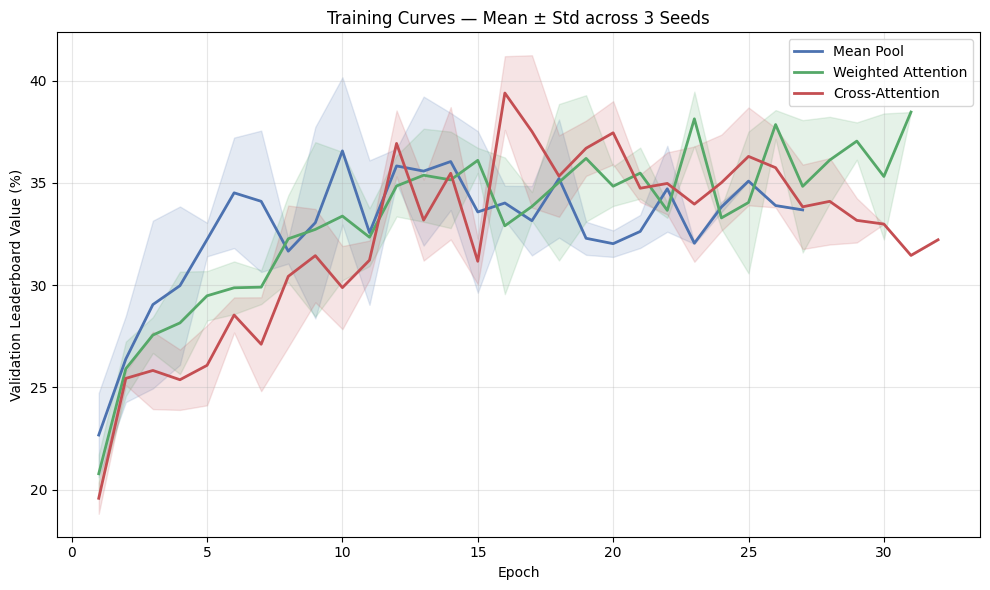

In [118]:
method_colors = {'mean': '#4C72B0', 'attention': '#55A868', 'cross_attention': '#C44E52'}
method_labels = {'mean': 'Mean Pool', 'attention': 'Weighted Attention', 'cross_attention': 'Cross-Attention'}

fig, ax = plt.subplots(figsize=(10, 6))

for method in ['mean', 'attention', 'cross_attention']:
    # Collect all seeds for this method
    seed_curves = {s: curves[(method, s)] for s in ['s1', 's2', 's3'] if (method, s) in curves}

    # Find common epoch range
    all_epochs = sorted(set(ep for epochs, _ in seed_curves.values() for ep in epochs))

    # Interpolate each seed to common epochs, build matrix
    lb_matrix = []
    for seed, (epochs, lbs) in seed_curves.items():
        ep_to_lb = dict(zip(epochs, lbs))
        lb_matrix.append([ep_to_lb.get(ep, np.nan) for ep in all_epochs])
    lb_matrix = np.array(lb_matrix)

    mean_lb = np.nanmean(lb_matrix, axis=0)
    std_lb = np.nanstd(lb_matrix, axis=0)

    ax.plot(all_epochs, mean_lb, color=method_colors[method], linewidth=2, label=method_labels[method])
    ax.fill_between(all_epochs, mean_lb - std_lb, mean_lb + std_lb,
                    color=method_colors[method], alpha=0.15)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Leaderboard Value (%)')
ax.set_title('Training Curves — Mean ± Std across 3 Seeds')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_training_curves.png', dpi=150)
plt.show()

## Conclusion

Cross-attention between camera views did **not** produce better foul classification than simpler aggregation strategies. The baseline weighted attention achieved the highest mean test LB (35.26), followed by parameter-free mean pooling (34.45), with cross-attention last (33.13). No pairwise comparison reached statistical significance (all p >= 0.25), though this is largely a consequence of the small number of seeds (N=3).

The most likely explanation is a **capacity-data mismatch**: cross-attention introduces ~1M additional parameters over the baseline's ~262k, but with only ~2300 training samples and 2 views per sample at training time, the extra capacity leads to overfitting rather than improved generalization. This is consistent with the higher seed variance observed for cross-attention, particularly on the offence severity task.

## Confusion Matrices

Side-by-side confusion matrices for the best seed of each method on the test set, for both tasks.

### Offence Severity (4 classes)

All three methods show a similar error pattern. The dominant behavior is predicting "No card" for most samples, which is the majority class. Specifically:
- **No offence** is partially recognized (10-12 correct out of ~21), but all methods confuse it with "No card" (5-7 samples).
- **No card** is the largest class and is predicted most often. Mean pool gets 81 correct, attention 66, and cross-attention 111, but cross-attention achieves this by over-predicting "No card" at the expense of other classes.
- **Yellow card** is poorly classified by all methods. Mean pool gets 27 right, attention 31, cross-attention only 20. Most yellow cards are misclassified as "No card".
- **Red card** (only 5 test samples) is essentially unlearned by all methods, with at most 1-2 correct predictions.

The error patterns are largely the same across methods: severity classification is driven by class imbalance rather than aggregation strategy. Cross-attention's tendency to over-predict "No card" (111 predictions in that column) suggests it learned a more conservative, majority-biased decision boundary.

In [119]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

gt_test_path = 'data/SoccerNet/mvfouls/Test/annotations.json'
with open(gt_test_path) as f:
    gt = json.load(f)

# Offence-severity classes (4-class)
offence_severity_map = {
    ('No offence', ''): 'No offence',
    ('No offence', '1.0'): 'No offence',
    ('Offence', '1.0'): 'No card',
    ('Offence', '3.0'): 'Yellow',
    ('Offence', '5.0'): 'Red',
}
offence_labels = ['No offence', 'No card', 'Yellow', 'Red']
action_labels = ['Tackling', 'Standing tackling', 'High leg', 'Holding',
                 'Pushing', 'Elbowing', 'Challenge', 'Dive']

def get_offence_severity_label(offence, severity):
    """Map offence + severity to 4-class label, matching SoccerNet evaluate logic."""
    if offence in ('No offence', 'No Offence'):
        return 'No offence'
    if severity == '1.0':
        return 'No card'
    if severity == '3.0':
        return 'Yellow'
    if severity == '5.0':
        return 'Red'
    return None

# Find best seed per method based on test_at_best_val_lb
best_seeds = df.loc[df.groupby('method')['test_at_best_val_lb'].idxmax()]

def load_predictions(method, seed):
    """Load the predictions JSON for the best val epoch of a given run."""
    row = df[(df['method'] == method) & (df['seed'] == seed)].iloc[0]
    epoch = int(row['best_val_epoch'])
    run_dir = list(run_dirs.values())[list(run_dirs.keys()).index((method, seed))]
    pred_file = os.path.join(run_dir, f'predicitions_test_epoch_{epoch}.json')
    with open(pred_file) as f:
        return json.load(f)

def build_confusion_data(predictions):
    """Build paired gt/pred lists for offence and action, filtering like SoccerNet evaluate."""
    gt_off, pred_off = [], []
    gt_act, pred_act = [], []

    for action_id, gt_action in gt['Actions'].items():
        action_class = gt_action.get('Action class', '')
        offence = gt_action.get('Offence', '')
        severity = gt_action.get('Severity', '')

        # Apply same filtering as SoccerNet evaluate
        if action_class == '' or action_class == 'Dont know':
            continue
        if (offence == '' or offence == 'Between') and action_class != 'Dive':
            continue
        if (severity in ('', '2.0', '4.0')) and action_class != 'Dive' and offence not in ('No offence', 'No Offence'):
            continue

        # Normalize
        if offence in ('', 'Between'):
            offence = 'Offence'
        if severity in ('', '2.0', '4.0'):
            severity = '1.0'
        if offence in ('No Offence', 'No offence'):
            offence = 'No offence'

        gt_os = get_offence_severity_label(offence, severity)
        if gt_os is None:
            continue

        if str(action_id) not in predictions.get('Actions', {}):
            continue

        pred_action = predictions['Actions'][str(action_id)]
        pred_offence = pred_action.get('Offence', '')
        pred_severity = pred_action.get('Severity', '')

        pred_os = get_offence_severity_label(pred_offence, pred_severity)
        if pred_os is None:
            pred_os = 'No card'  # fallback

        gt_off.append(gt_os)
        pred_off.append(pred_os)
        gt_act.append(action_class)
        pred_act.append(pred_action.get('Action class', ''))

    return gt_off, pred_off, gt_act, pred_act

print("Best seed per method:")
print(best_seeds[['method', 'seed', 'test_at_best_val_lb']])

Best seed per method:
            method seed  test_at_best_val_lb
3        attention   s1              36.7679
6  cross_attention   s1              35.9981
1             mean   s2              38.4128


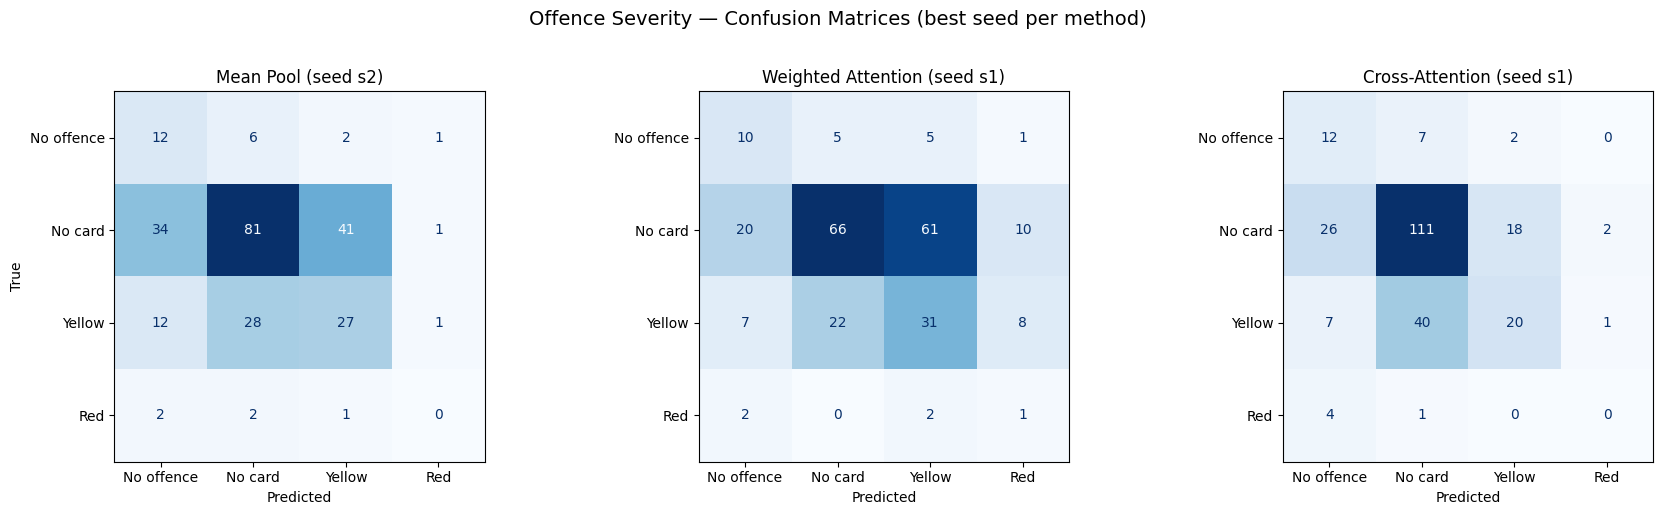

In [120]:
# Offence severity confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_order = ['mean', 'attention', 'cross_attention']

for ax, method in zip(axes, method_order):
    seed = best_seeds[best_seeds['method'] == method]['seed'].values[0]
    preds = load_predictions(method, seed)
    gt_off, pred_off, _, _ = build_confusion_data(preds)
    cm = confusion_matrix(gt_off, pred_off, labels=offence_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=offence_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{method_labels[method]} (seed {seed})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if method == 'mean' else '')

fig.suptitle('Offence Severity — Confusion Matrices (best seed per method)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_offence.png', dpi=150, bbox_inches='tight')
plt.show()

### Action Type (8 classes)

The action confusion matrices reveal that all three methods struggle with the same fundamental challenges:
- **Tackling and Standing tackling** dominate predictions. These are the two most common classes and are visually similar. All methods confuse them heavily with each other (e.g. 31 true Tackling predicted as Standing tackling by mean pool, 26 by attention, 17 by cross-attention).
- **Challenge** is the third most common class but is frequently misclassified as Tackling or Standing tackling across all methods (8-14 samples).
- **Rare classes are barely predicted.** High leg, Pushing, and Dive have very few test samples, and all methods struggle to predict them. Elbowing is an exception: mean pool gets 7 correct, attention gets 5, and cross-attention gets 8, suggesting that elbowing has a distinctive visual signature that even simple models can learn.
- **Holding** shows an interesting difference: attention gets 7 correct vs mean pool's 7 and cross-attention's 17. Cross-attention appears to over-predict Holding.

Overall, the confusion patterns are similar across all three methods. The primary errors come from class imbalance and visual similarity between foul types (especially Tackling vs Standing tackling), not from the aggregation strategy. This reinforces the conclusion that the bottleneck is in the data and backbone representation, not in how views are combined.

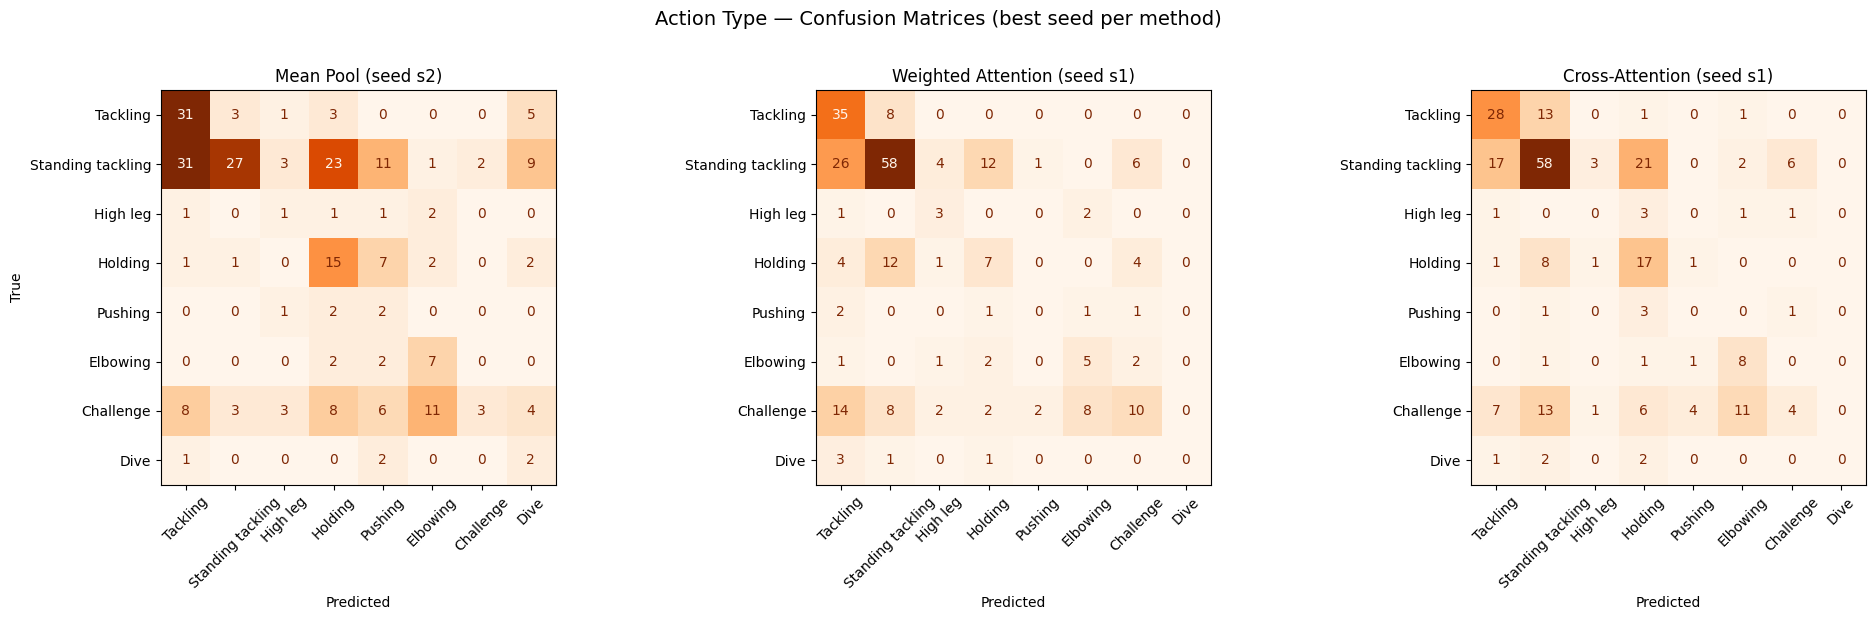

In [121]:
# Action type confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, method in zip(axes, method_order):
    seed = best_seeds[best_seeds['method'] == method]['seed'].values[0]
    preds = load_predictions(method, seed)
    _, _, gt_act, pred_act = build_confusion_data(preds)
    cm = confusion_matrix(gt_act, pred_act, labels=action_labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=action_labels)
    disp.plot(ax=ax, cmap='Oranges', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{method_labels[method]} (seed {seed})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if method == 'mean' else '')

fig.suptitle('Action Type — Confusion Matrices (best seed per method)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_action.png', dpi=150, bbox_inches='tight')
plt.show()